In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("D:\DATA SCIENCE\dataset\complaints_processed.csv")

In [6]:
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name


In [7]:
df[df['narrative']=='name']

,Unnamed: 0,product,narrative
162415,162415,debt_collection,name
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name
162420,162420,credit_reporting,name


In [8]:
df['product'].value_counts()

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

In [9]:
df_major = df[df['product'] == 'credit_reporting'].sample(13000, random_state=42)
df_other = df[df['product'] != 'credit_reporting']

df_new = pd.concat([df_major, df_other])
df_new.drop(columns='Unnamed: 0',inplace=True)


df_major = df_new[df_new['product'] == 'debt_collection'].sample(13000, random_state=42)
df_other = df_new[df_new['product'] != 'debt_collection']

df_new = pd.concat([df_major, df_other])

df_new = df_new[df_new['narrative'] != 'name']

df_new['product'].value_counts()

product
mortgages_and_loans    18990
credit_card            15564
retail_banking         13536
debt_collection        12999
credit_reporting       12999
Name: count, dtype: int64

In [10]:
df=df_new.copy()

In [11]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [12]:
df

,product,narrative
0,debt_collection,removed credit report exxxx successfully dispu...
1,mortgages_and_loans,following last complaint regarding misapplicat...
2,debt_collection,victom identity theft charge made credit card ...
3,retail_banking,enrolled debt settlement offered freedom debt ...
4,mortgages_and_loans,past issue mortgage solution colorado llc spec...
...,...,...
74083,retail_banking,cashapped person person ended deleting form co...
74084,debt_collection,contacted request alarm system installed incom...
74085,retail_banking,debit card charged pool company someone fraudu...
74086,debt_collection,account unware debt opportunity dispute please...


In [13]:
df = df.dropna(subset=['narrative'])
df['narrative'] = df['narrative'].astype(str)

C:\Users\Sanskar\AppData\Local\Temp\ipykernel_24360\1900196235.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['narrative'] = df['narrative'].astype(str)


In [14]:
from sklearn.model_selection import train_test_split

X = df['narrative']
y = df['product']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y,random_state=42
)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_labeled = le.fit_transform(y_train)
y_test_labeled = le.transform(y_test)

In [16]:
y_train.value_counts()

product
mortgages_and_loans    13293
credit_card            10895
retail_banking          9474
debt_collection         9098
credit_reporting        9098
Name: count, dtype: int64

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [18]:
tokenizer = Tokenizer(
    num_words=30000

)

tokenizer.fit_on_texts(X_train)

In [19]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [20]:
len(tokenizer.word_index)

33183

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 88

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='pre')

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout,LSTM

In [23]:
model = Sequential()

# 🔹 Embedding layer
model.add(Embedding(input_dim=30000, output_dim=200, input_length=60))

# 🔹 GRU layer
model.add(LSTM(128))

# 🔹 Dropout (overfitting control)
model.add(Dropout(0.5))

# 🔹 Output layer
model.add(Dense(5, activation='softmax'))  # 5 classes

d:\clear\xyx\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [24]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train_pad,
    y_train_labeled,
    epochs=15,
    batch_size=300,
    validation_data=(X_test_pad, y_test_labeled)
)

Epoch 1/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 52s 290ms/step - accuracy: 0.7097 - loss: 0.7895 - val_accuracy: 0.8239 - val_loss: 0.5470
Epoch 2/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 45s 258ms/step - accuracy: 0.8502 - loss: 0.4682 - val_accuracy: 0.8398 - val_loss: 0.4881
Epoch 3/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 45s 261ms/step - accuracy: 0.8743 - loss: 0.3968 - val_accuracy: 0.8384 - val_loss: 0.5132
Epoch 4/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 45s 259ms/step - accuracy: 0.8932 - loss: 0.3399 - val_accuracy: 0.8353 - val_loss: 0.5183
Epoch 5/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 47s 271ms/step - accuracy: 0.9057 - loss: 0.3003 - val_accuracy: 0.8268 - val_loss: 0.5717
Epoch 6/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 46s 268ms/step - accuracy: 0.9141 - loss: 0.2728 - val_accuracy: 0.8272 - val_loss: 0.5724
Epoch 7/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 48s 277ms/step - accuracy: 0.9202 - loss: 0.2506 - val_accuracy: 0.8261 - val_loss: 0.6199
Epoch 8/15
173/173 ━━━━━━━━━━━━━━━━━━━━ 49s 280ms/step - accuracy: 0.9262 - loss: 0

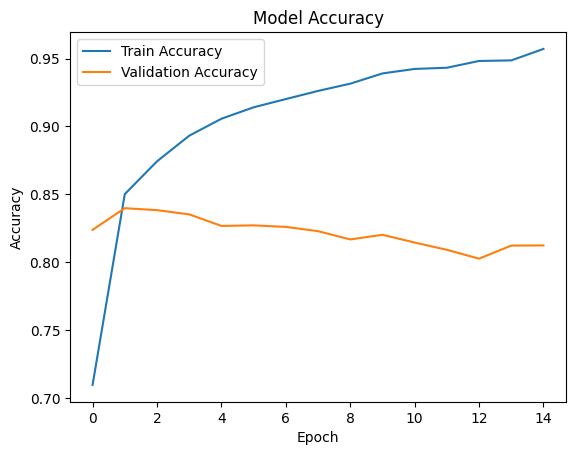

In [27]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

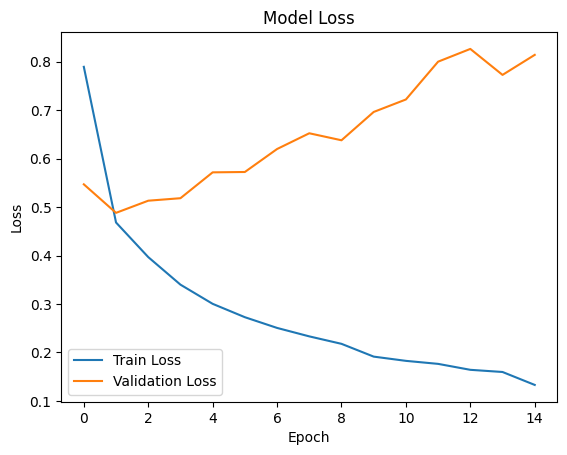

In [28]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [ ]:
import pickle

# tokenizer save
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# label encoder save
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# model save
model.save('model.h5')

: 